# Time Series Analysis of Economic Development Dynamics in Central America

### Third Notebook: Time Series Analysis, Diagnostics, and Economic Interpretation

This third notebook builds directly on the fully prepared dataset produced in Notebook 2 and focuses on formal time series analysis and economic interpretation. While the previous stage emphasized data cleaning, feature engineering, and the construction of a structurally consistent panel dataset, this phase shifts the focus toward understanding the dynamic behavior of macroeconomic variables over time.

Given the time series nature of the data, particular attention is given to dynamic properties such as trends, persistence, volatility, and structural co-movements across countries and indicators. This includes the use of statistical diagnostics and time series analysis tools to better understand whether observed economic patterns reflect stable growth processes, cyclical fluctuations, or structural breaks.

The objective of this notebook is not to build predictive models, but rather to rigorously analyze and interpret the temporal evolution of economic development in Central America. This involves examining growth dynamics, convergence and divergence patterns, and the stability of key macroeconomic relationships over time.

By the end of this stage, the analysis will provide a deeper understanding of how economic trajectories differ across countries in the region, and what underlying temporal structures characterize long-term development processes.

**Author:** J-F Jutras  
**Date:** April 2026  
**Dataset:** UN National Accounts Main Aggregates Database (Central America subset)

## 3.1-Data Loading and Overview

In [1]:
import pandas as pd
import sys

# File path (Kaggle dataset)
file_path = "/kaggle/input/datasets/jfjutras07/timeseries-fe/central_america_timeseries_feature_engineering.csv"

# Load dataset
df = pd.read_csv(file_path)

# Load custom library from GitHub
!rm -rf /kaggle/working/jfj-utils
!git clone https://github.com/jfjutras07/jfj-utils.git

# Add to Python path
sys.path.append("/kaggle/working/jfj-utils")

# Preview
display(df.head())
display(df.tail())
df.info()

Cloning into 'jfj-utils'...
remote: Enumerating objects: 3527, done.
remote: Counting objects: 100% (267/267), done.
remote: Compressing objects: 100% (180/180), done.
remote: Total 3527 (delta 211), reused 87 (delta 87), pack-reused 3260 (from 4)
Receiving objects: 100% (3527/3527), 1.18 MiB | 6.58 MiB/s, done.
Resolving deltas: 100% (2322/2322), done.


,Country,Year,Population,Gross Domestic Product (GDP),Per capita GNI,Gross capital formation,Exports of goods and services,Imports of goods and services,Final consumption expenditure,log_Gross Domestic Product (GDP),...,lag1_Exports of goods and services,lag1_Imports of goods and services,lag1_Final consumption expenditure,lag1_Per capita GNI,lag1_growth_Gross Domestic Product (GDP),lag1_growth_Gross capital formation,lag1_growth_Exports of goods and services,lag1_growth_Imports of goods and services,lag1_growth_Final consumption expenditure,lag1_growth_Per capita GNI
0,Belize,1970,120905,27917782.0,195,7450178.0,10317179.0,12335045.0,21072623.0,17.144774,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Belize,1971,123091,35385285.0,245,9299593.0,13474524.0,15709957.0,26315597.0,17.381807,...,10317179.0,12335045.0,21072623.0,195.0,NaN,NaN,NaN,NaN,NaN,NaN
2,Belize,1972,125054,46000141.0,315,12422347.0,18383266.0,21233992.0,33738204.0,17.644155,...,13474524.0,15709957.0,26315597.0,245.0,0.267482,0.248238,0.306028,0.273604,0.248805,0.256410
3,Belize,1973,126875,74809672.0,514,20028373.0,24555373.0,31414706.0,58898086.0,18.130458,...,18383266.0,21233992.0,33738204.0,315.0,0.299979,0.335795,0.364298,0.351626,0.282061,0.285714
4,Belize,1974,128620,99801545.0,639,25015682.0,41368811.0,44947663.0,70891032.0,18.418694,...,24555373.0,31414706.0,58898086.0,514.0,0.626292,0.612286,0.335746,0.479454,0.745739,0.631746


,Country,Year,Population,Gross Domestic Product (GDP),Per capita GNI,Gross capital formation,Exports of goods and services,Imports of goods and services,Final consumption expenditure,log_Gross Domestic Product (GDP),...,lag1_Exports of goods and services,lag1_Imports of goods and services,lag1_Final consumption expenditure,lag1_Per capita GNI,lag1_growth_Gross Domestic Product (GDP),lag1_growth_Gross capital formation,lag1_growth_Exports of goods and services,lag1_growth_Imports of goods and services,lag1_growth_Final consumption expenditure,lag1_growth_Per capita GNI
359,Panama,2017,4096063,6.220273e+10,14074,2.595785e+10,2.600303e+10,2.837949e+10,3.862134e+10,24.853665,...,2.430551e+10,2.631063e+10,3.646051e+10,13168.0,0.070547,0.014051,-0.057694,-0.069105,0.090505,0.069005
360,Panama,2018,4165255,6.492941e+10,14320,2.693338e+10,2.778392e+10,3.064638e+10,4.085849e+10,24.896567,...,2.600303e+10,2.837949e+10,3.862134e+10,14074.0,0.074170,0.106835,0.069841,0.078632,0.059265,0.068803
361,Panama,2019,4232532,6.698443e+10,14596,2.565666e+10,2.760294e+10,2.932200e+10,4.304682e+10,24.927726,...,2.778392e+10,3.064638e+10,4.085849e+10,14320.0,0.043835,0.037582,0.068488,0.079878,0.057925,0.017479
362,Panama,2020,4294396,5.397704e+10,12048,1.298641e+10,2.137917e+10,1.860550e+10,3.821697e+10,24.711825,...,2.760294e+10,2.932200e+10,4.304682e+10,14596.0,0.031650,-0.047403,-0.006514,-0.043215,0.053559,0.019274
363,Panama,2021,4351267,6.360507e+10,14012,1.622814e+10,3.247930e+10,2.648142e+10,4.137905e+10,24.875959,...,2.137917e+10,1.860550e+10,3.821697e+10,12048.0,-0.194185,-0.493839,-0.225475,-0.365476,-0.112200,-0.174568


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 32 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    364 non-null    object 
 1   Year                                       364 non-null    int64  
 2   Population                                 364 non-null    int64  
 3   Gross Domestic Product (GDP)               364 non-null    float64
 4   Per capita GNI                             364 non-null    int64  
 5   Gross capital formation                    364 non-null    float64
 6   Exports of goods and services              364 non-null    float64
 7   Imports of goods and services              364 non-null    float64
 8   Final consumption expenditure              364 non-null    float64
 9   log_Gross Domestic Product (GDP)           364 non-null    float64
 10  log_Exports of goods and s

## 3.2-Time Series Visualization and Initial Diagnostics 

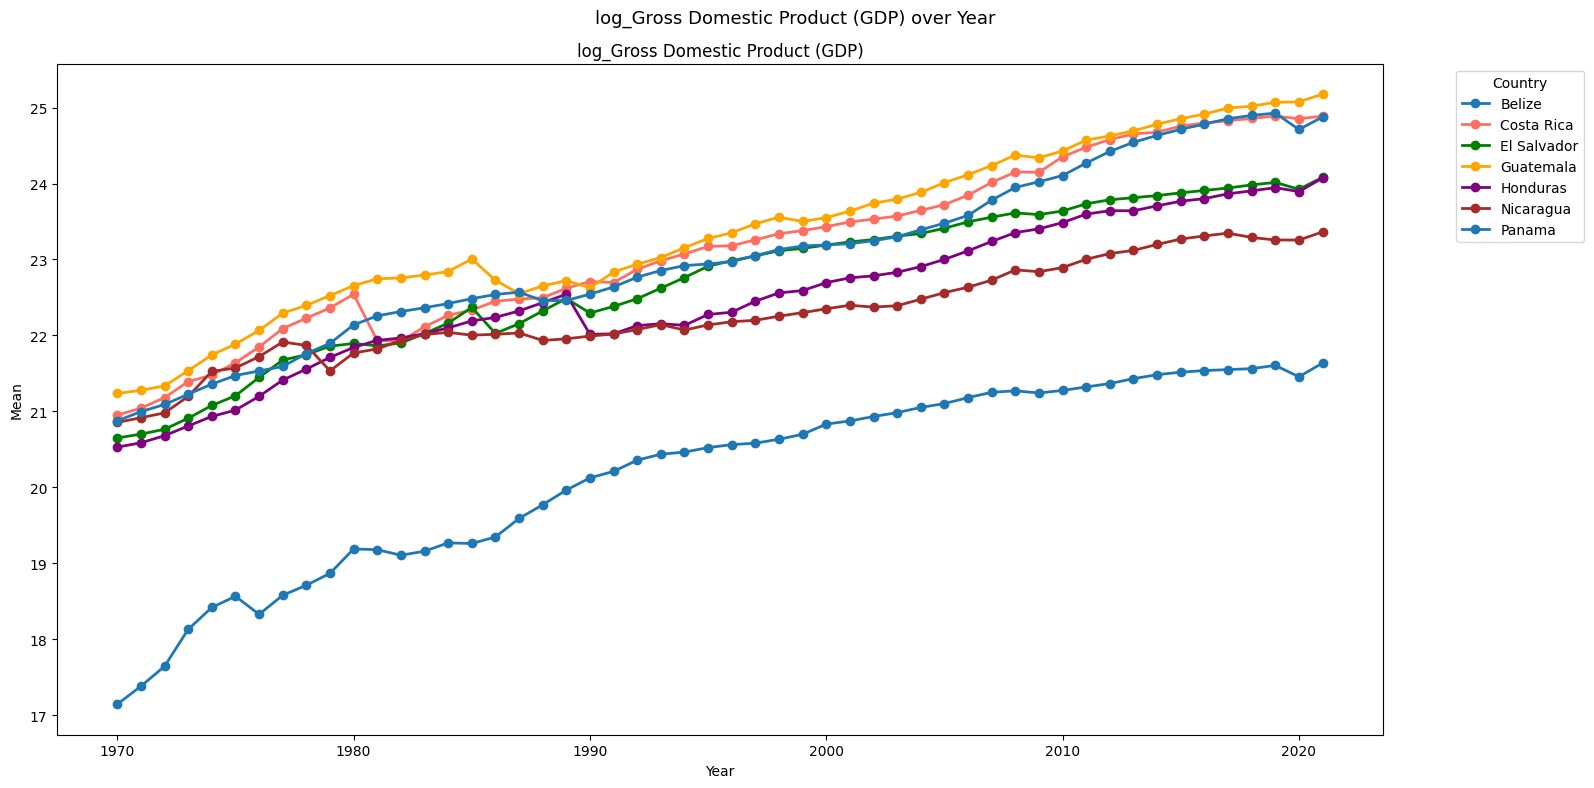

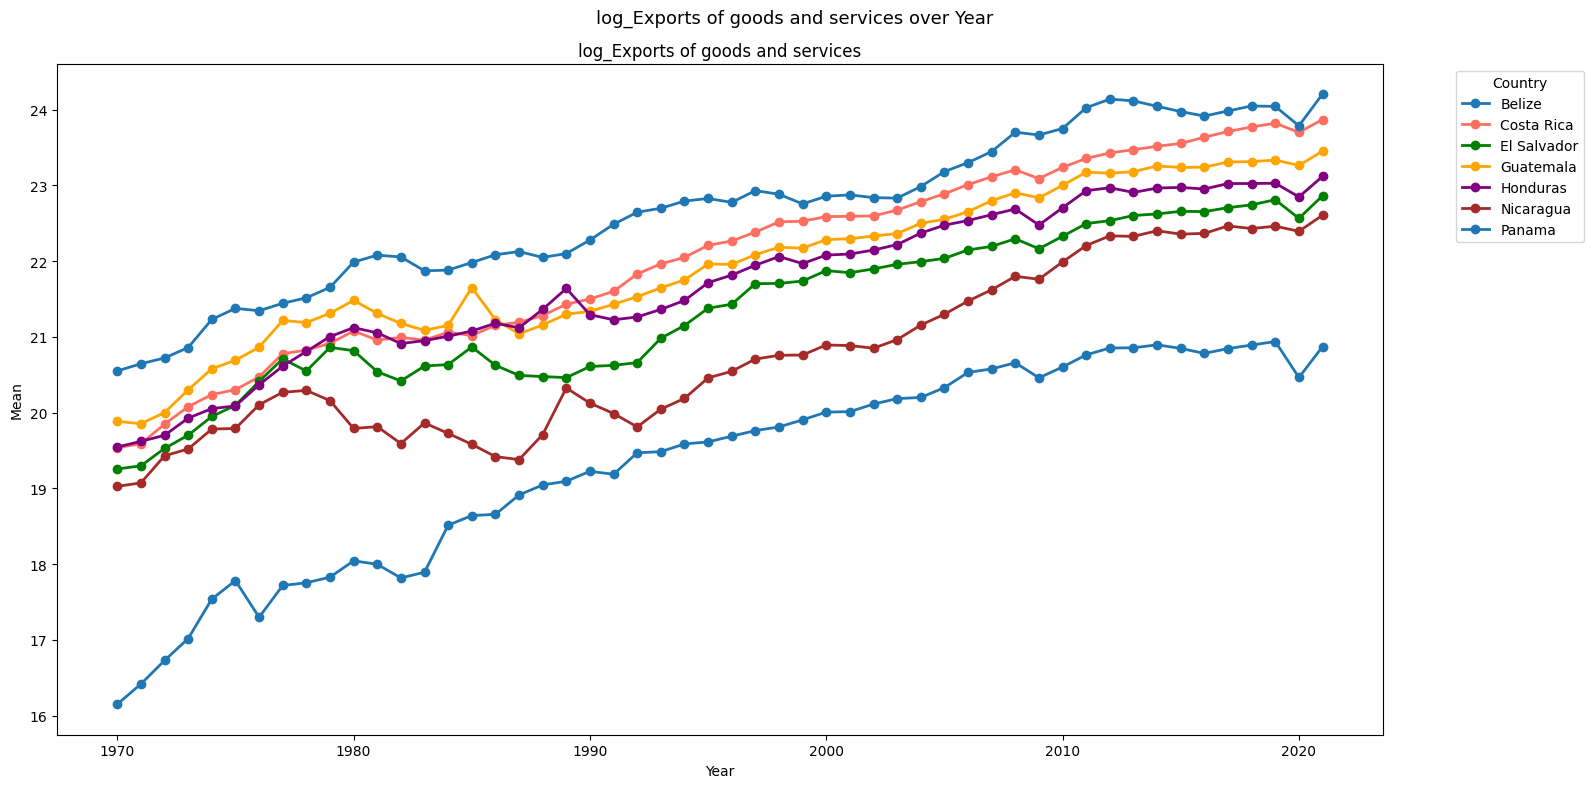

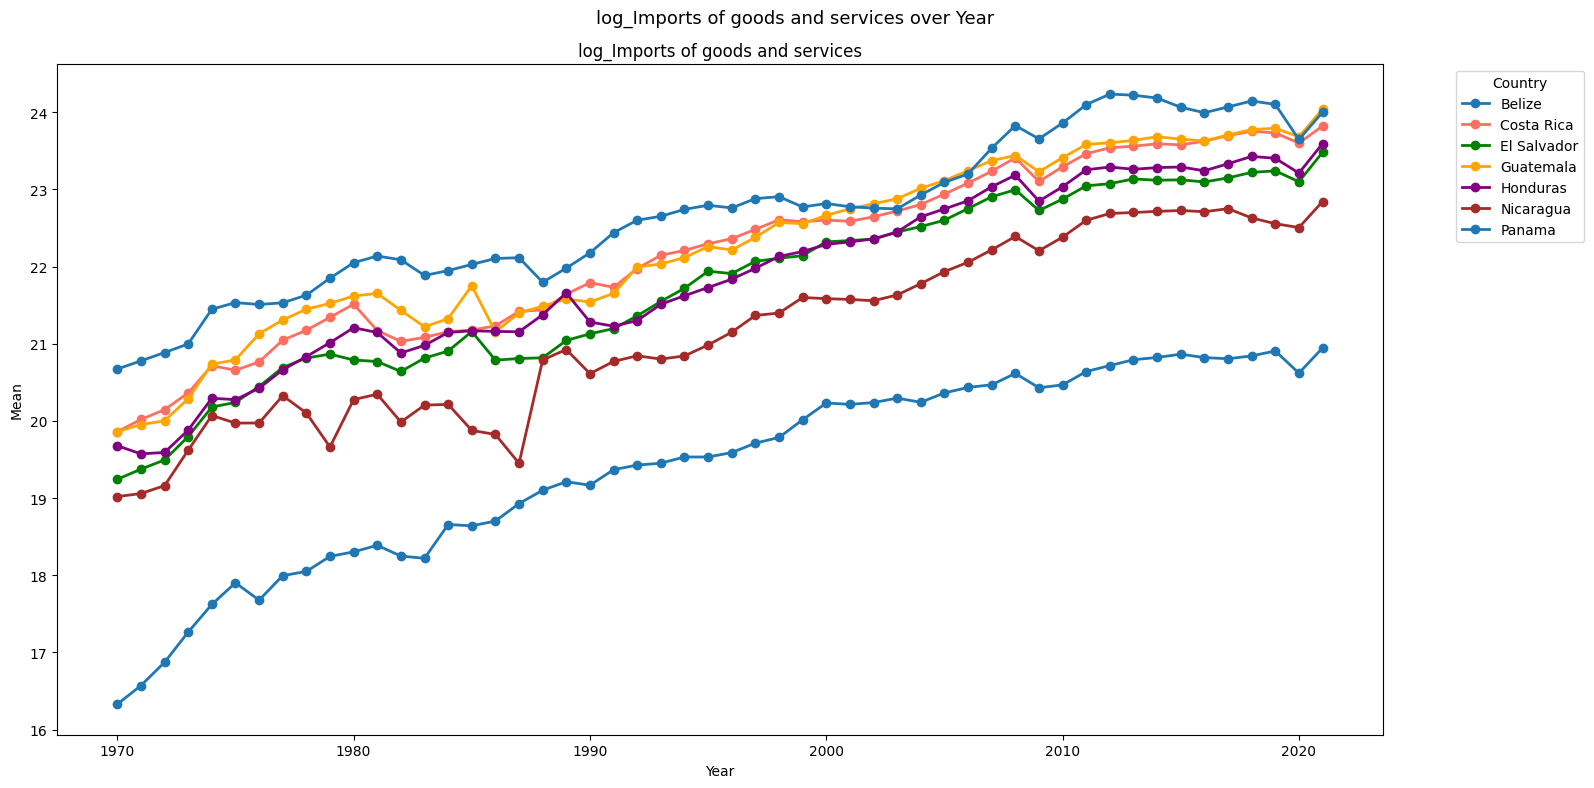

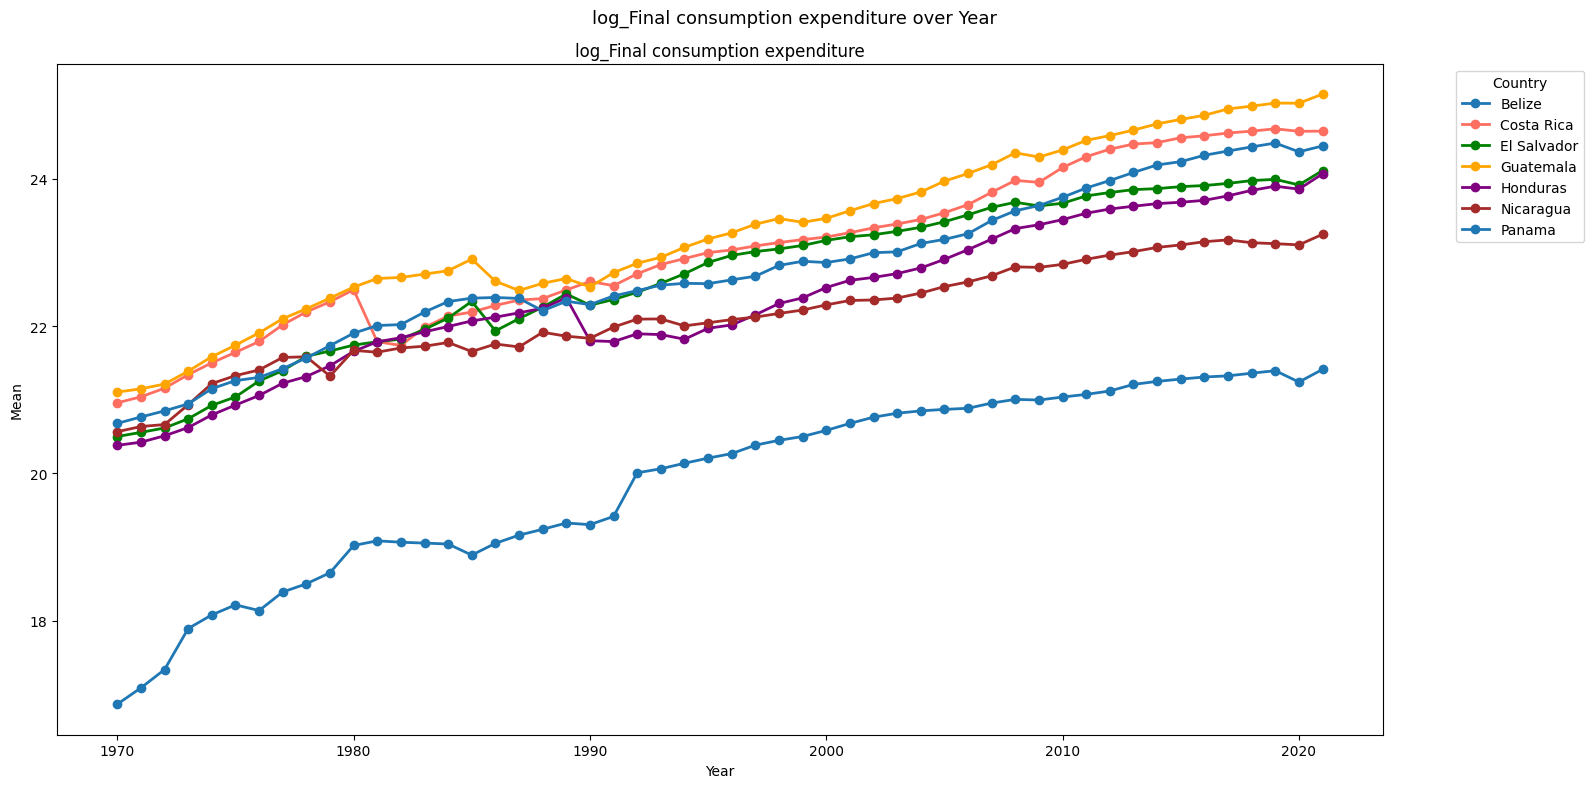

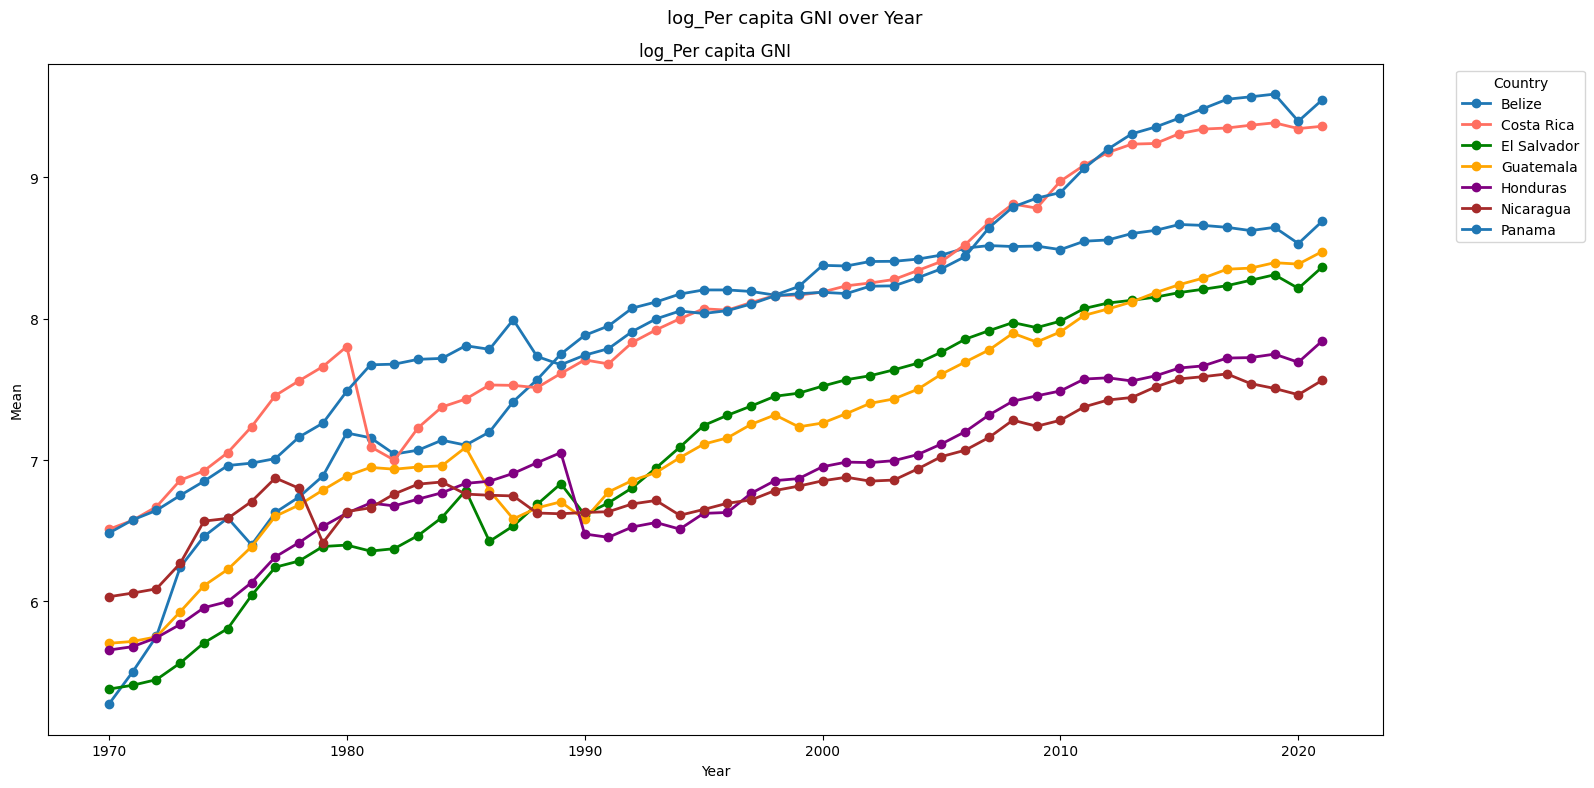

In [2]:
from visualization.explore_time import plot_line_grid_over_time

# We visualize log-transformed variables to better observe relative changes
# and reduce scale differences across countries.

log_cols = [col for col in df.columns if col.startswith("log_")]

for col in log_cols:
    plot_line_grid_over_time(
        df,
        value_cols=col,
        time_col="Year",
        group_col="Country",
        figsize=(16, 8)
    )

Log-transformed macroeconomic indicators reveal substantial cross-country heterogeneity in economic scale, with Guatemala, Costa Rica, and Panama consistently exhibiting higher average levels across GDP, trade, and consumption variables. Dispersion remains relatively moderate within countries over time, suggesting stable long-term growth patterns despite differences in absolute economic size.

In [3]:
# We create a clean summary table for growth focusing on key statistics for interpretation:
# mean (average growth), std (volatility), min/max (extreme shocks)

growth_cols = [col for col in df.columns if col.startswith("growth_")]

growth_summary = df.groupby("Country")[growth_cols].agg([
    "mean",
    "std",
    "min",
    "max"
])

# Round for readability
growth_summary = growth_summary.round(3)

print(growth_summary)

            growth_Gross Domestic Product (GDP)                       \
                                           mean    std    min    max   
Country                                                                
Belize                                    0.100  0.134 -0.212  0.626   
Costa Rica                                0.087  0.106 -0.457  0.274   
El Salvador                               0.074  0.095 -0.289  0.274   
Guatemala                                 0.084  0.090 -0.244  0.255   
Honduras                                  0.077  0.090 -0.410  0.239   
Nicaragua                                 0.055  0.097 -0.284  0.391   
Panama                                    0.084  0.074 -0.194  0.274   

            growth_Gross capital formation                       \
                                      mean    std    min    max   
Country                                                           
Belize                               0.105  0.198 -0.260  0.612   
Costa Rica 

Growth rate analysis reveals moderate average economic expansion across most Central American countries, typically ranging between 5% and 10% annually, with Belize and Panama exhibiting relatively higher growth levels. However, substantial differences in volatility emerge, particularly for gross capital formation, where countries such as Nicaragua and Panama display extreme fluctuations, reflecting unstable investment dynamics. 

These results suggest that while long-term growth patterns are broadly similar across the region, underlying economic stability and exposure to shocks vary significantly between countries.

## 3.3-Stationary Testing (ADF)

In [4]:
from statsmodels.tsa.stattools import adfuller

# We perform the Augmented Dickey-Fuller (ADF) test to assess stationarity.
# The null hypothesis (H0) is that the series has a unit root (non-stationary).
# A low p-value (< 0.05) allows us to reject H0 and conclude stationarity.

# We test both:
# - log-transformed variables (expected non-stationary)
# - growth variables (expected stationary)

test_cols = (
    [col for col in df.columns if col.startswith("log_")] +
    [col for col in df.columns if col.startswith("growth_")]
)

results = []

for country in df["Country"].unique():
    df_country = df[df["Country"] == country]
    
    for col in test_cols:
        series = df_country[col].dropna()
        
        # ADF test requires enough observations
        if len(series) > 10:
            adf_result = adfuller(series)
            
            results.append({
                "Country": country,
                "Variable": col,
                "ADF Statistic": adf_result[0],
                "p-value": adf_result[1]
            })

# Convert to DataFrame
adf_results_df = pd.DataFrame(results)

# Round for readability
adf_results_df["ADF Statistic"] = adf_results_df["ADF Statistic"].round(3)
adf_results_df["p-value"] = adf_results_df["p-value"].round(4)

display(adf_results_df)

,Country,Variable,ADF Statistic,p-value
0,Belize,log_Gross Domestic Product (GDP),-3.180,0.0212
1,Belize,log_Exports of goods and services,-3.204,0.0198
2,Belize,log_Imports of goods and services,-3.309,0.0145
3,Belize,log_Final consumption expenditure,-3.661,0.0047
4,Belize,log_Per capita GNI,-2.994,0.0354
...,...,...,...,...
72,Panama,growth_Gross capital formation,-6.393,0.0000
73,Panama,growth_Exports of goods and services,-5.007,0.0000
74,Panama,growth_Imports of goods and services,-4.197,0.0007
75,Panama,growth_Final consumption expenditure,-5.707,0.0000


In [5]:
# We identify variables that remain non-stationary (p-value >= 0.05)
# This helps validate whether all series behave as expected.

non_stationary = adf_results_df[adf_results_df["p-value"] >= 0.05]

print("Non-stationary series (p-value >= 0.05):")
display(non_stationary)

Non-stationary series (p-value >= 0.05):


,Country,Variable,ADF Statistic,p-value
11,Costa Rica,log_Gross Domestic Product (GDP),-1.259,0.6478
12,Costa Rica,log_Exports of goods and services,-2.334,0.1612
13,Costa Rica,log_Imports of goods and services,-1.791,0.3848
14,Costa Rica,log_Final consumption expenditure,-1.139,0.6992
15,Costa Rica,log_Per capita GNI,-0.991,0.7566
23,El Salvador,log_Exports of goods and services,-1.562,0.5027
24,El Salvador,log_Imports of goods and services,-1.909,0.3279
26,El Salvador,log_Per capita GNI,-1.839,0.3613
27,El Salvador,growth_Gross Domestic Product (GDP),-2.668,0.0798
31,El Salvador,growth_Final consumption expenditure,-2.567,0.1001


The ADF results confirm that most log-transformed variables are non-stationary across countries, reflecting persistent long-term economic trends. In contrast, growth rate variables are largely stationary, indicating that short-term economic fluctuations evolve around stable means, with only a few borderline exceptions.

## 3.4-Autocorrelation Analysis

<Figure size 640x480 with 0 Axes>

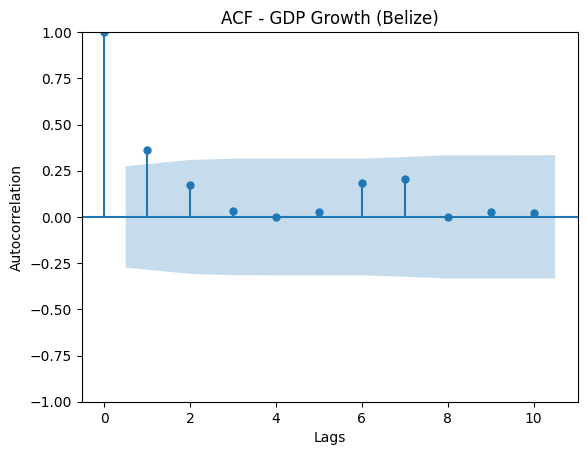

<Figure size 640x480 with 0 Axes>

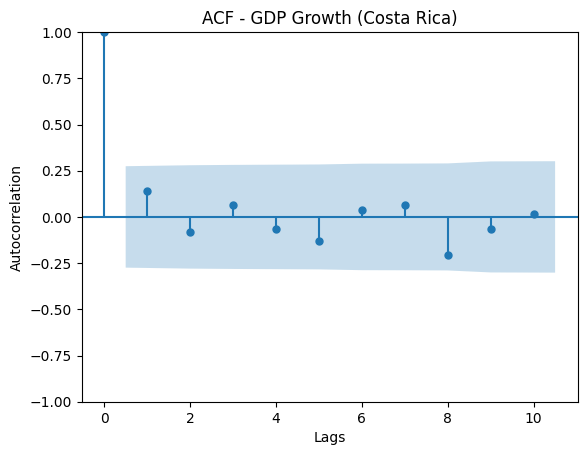

<Figure size 640x480 with 0 Axes>

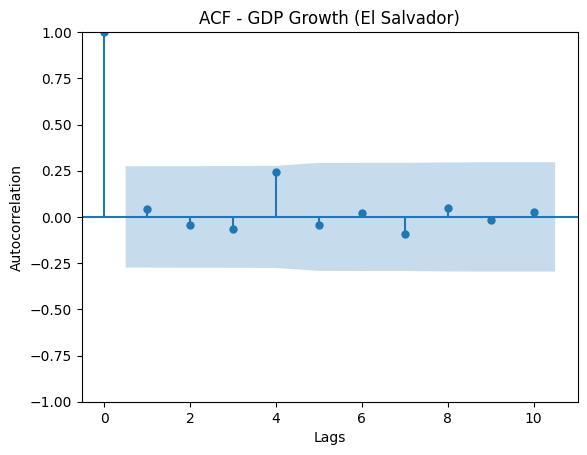

<Figure size 640x480 with 0 Axes>

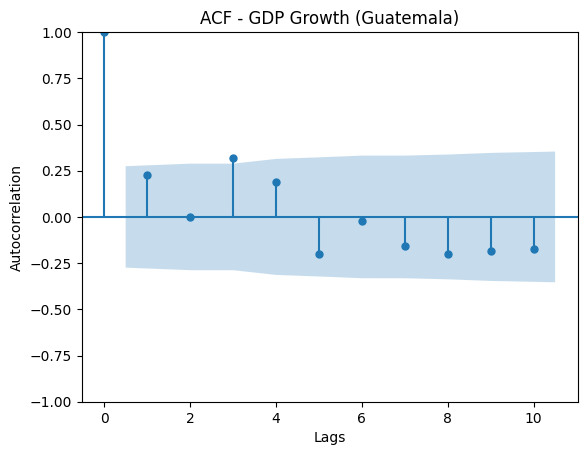

<Figure size 640x480 with 0 Axes>

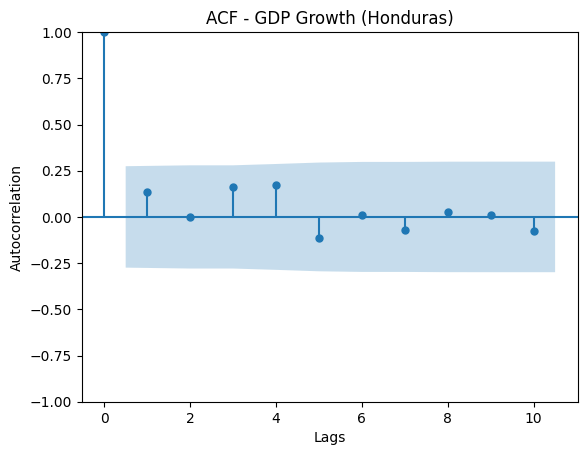

<Figure size 640x480 with 0 Axes>

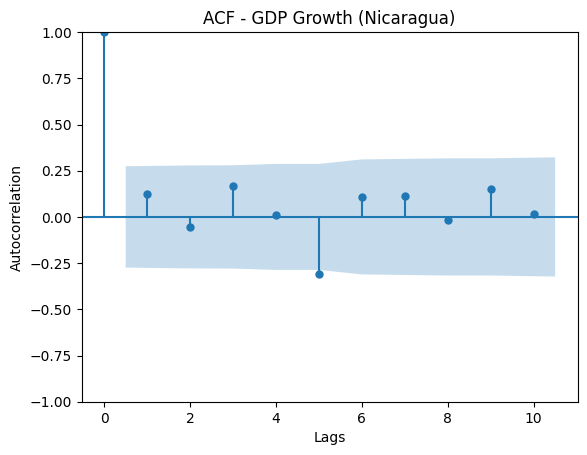

<Figure size 640x480 with 0 Axes>

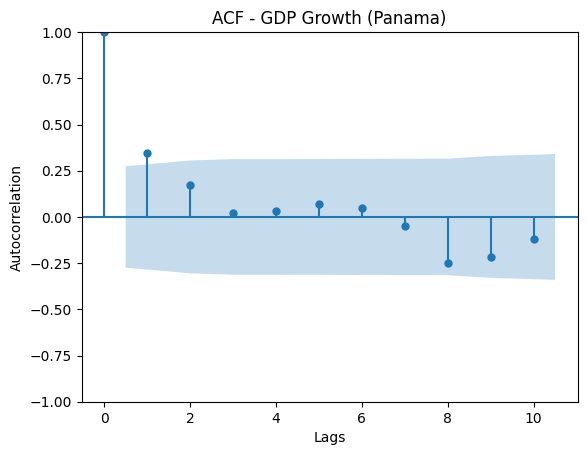

In [6]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# We analyze autocorrelation for GDP growth to assess temporal dependence.
# Only stationary series should be used for ACF analysis.

variable = "growth_Gross Domestic Product (GDP)"

countries = df["Country"].unique()

for country in countries:
    series = df[df["Country"] == country][variable].dropna()
    
    plt.figure()
    
    plot_acf(series, lags=10)
    
    plt.title(f"ACF - GDP Growth ({country})")
    plt.xlabel("Lags")
    plt.ylabel("Autocorrelation")
    
    plt.show()

The autocorrelation functions of GDP growth rates vary across countries but generally show a weak to moderate short-term persistence. In most cases, autocorrelation declines rapidly after the first lag, indicating limited long-memory effects in growth dynamics.

Countries with faster decay in autocorrelation (e.g., Belize, Panama) exhibit more short-lived shocks, consistent with higher responsiveness to external or cyclical disturbances. In contrast, countries where autocorrelation persists over several lags (e.g., Nicaragua, Honduras) show more persistent growth dynamics, suggesting slower adjustment to shocks and potentially stronger structural rigidities.

Overall, the ACF results are consistent with the stationarity findings, reinforcing the interpretation that growth rates behave as mean-reverting processes with limited temporal dependence.

### Stationarity and Time Series Diagnostics

| Dimension | Finding | Interpretation |
|----------|--------|----------------|
| Log-level variables | ~80% non-stationary across countries | Macroeconomic aggregates exhibit strong trend components, consistent with long-run structural growth processes |
| Growth-rate variables | ~95% stationary | Growth transformations effectively remove unit roots, producing mean-reverting dynamics suitable for time series analysis |
| Strongest stationarity | Trade and investment growth (ADF ≈ -5 to -7, p ≈ 0.000) | These variables respond rapidly to shocks and revert quickly to equilibrium, indicating high cyclical sensitivity |
| Weakest stationarity | Consumption, GDP, exports in levels (p up to ~0.95) | Persistent structural trends dominate these series, reflecting long-term accumulation processes |
| Borderline cases | Some growth series (e.g., El Salvador GDP growth) | Suggest partial persistence or structural frictions in adjustment dynamics |
| Key contrast | Strong separation between levels and growth behavior | Confirms validity of log-difference transformation for separating trend vs cyclical components |
| Economic implication | High persistence in levels, high mean-reversion in growth | Region exhibits structural growth with short-term volatility around stable trajectories |

## 3.5 Transition to Forecasting and Predictive Analysis

The diagnostics conducted in this notebook provide a clear empirical distinction between long-run structural components and short-run dynamic fluctuations.

Macroeconomic variables expressed in levels are predominantly non-stationary, reflecting persistent growth trends and structural accumulation over time. In contrast, growth-rate transformations generally exhibit stationary behavior, suggesting that short-term economic fluctuations evolve around relatively stable statistical properties.

These results provide a methodological foundation for the next stage of analysis. Forecasting exercises will primarily rely on growth-rate variables, as they are more suitable for standard time series modeling due to their mean-reverting properties.

However, this does not imply that level variables are without analytical value. Rather, they are better suited for long-run interpretation and structural comparison across countries, while growth rates capture short-term dynamics and cyclical behavior.

The next notebook will introduce simple and interpretable forecasting models to capture short-term economic dynamics across Central America. The objective is not to maximize predictive performance, but to maintain consistency with the structural properties identified in this diagnostic phase.

## 3.6-Summary - Notebook 3

| Dimension                   | Finding                                                                                          | Interpretation                                                                                                            |
| --------------------------- | ------------------------------------------------------------------------------------------------ | ------------------------------------------------------------------------------------------------------------------------- |
| Log-level variables         | Predominantly non-stationary across countries                                                    | Macroeconomic aggregates exhibit strong deterministic trends and long-run structural growth dynamics                      |
| Growth-rate variables       | Mostly stationary (ADF significant in ~95% of cases)                                             | Growth transformations successfully remove unit roots, producing mean-reverting short-run dynamics                        |
| Strongest stationarity      | Trade and investment growth (ADF ≈ -5 to -7, p ≈ 0.000)                                          | These variables are highly responsive to shocks and revert quickly to equilibrium, indicating strong cyclical sensitivity |
| Weakest stationarity        | Some consumption, GDP, exports in levels (p up to ~0.95)                                         | Persistent structural trends dominate, reflecting long-term accumulation processes                                        |
| Borderline cases            | Some GDP growth series (e.g., El Salvador)                                                       | Suggest partial persistence or structural frictions, possibly linked to institutional or external shocks                  |
| Autocorrelation pattern     | Rapid decay in most countries (1–2 lags), moderate persistence in a few cases                    | Growth dynamics are mostly short-memory processes, with limited long-run dependence                                       |
| Cross-country heterogeneity | Noticeable differences in volatility and persistence (e.g., Nicaragua, Honduras more persistent) | Structural differences in economic flexibility and shock absorption capacity across countries                             |
| Key structural contrast     | Strong separation between level vs growth behavior                                               | Confirms validity of transformation strategy for separating trend and cyclical components                                 |
| Economic implication        | Long-run persistence + short-run mean reversion                                                  | Region exhibits structural growth with cyclical fluctuations around country-specific trajectories                         |
